In [35]:
# https://www.census.gov/data/datasets/time-series/demo/cps/cps-supp_cps-repwgt/cps-food-security.html#cpssupps 
# https://www.ers.usda.gov/data-products/food-security-in-the-united-states/

import pandas as pd
import io

def load_cps_data_from_df(df):
    """Alternative version that accepts an already-loaded DataFrame"""
    # Create a copy to avoid modifying the original
    df = df.copy()
    
    # Basic data cleaning
    # Replace -1, -2, -3, -9 with NaN for better analysis
    df = df.replace({-1: pd.NA, -2: pd.NA, -3: pd.NA, -9: pd.NA})
    
    # Convert weight variables by dividing by 10000 (as per documentation)
    weight_cols = [col for col in df.columns if col.startswith(('HW', 'PW'))]
    for col in weight_cols:
        df[col] = df[col] / 10000
    
    return df

def glimpse(df):
    """
    Display DataFrame info similar to R's glimpse function, with additional summary info.
    Converts the index to a column if it's not a default RangeIndex.
    """
    # Handle index: convert to column if it's not a default RangeIndex
    if not isinstance(df.index, pd.RangeIndex):
        df = df.reset_index()
        print("Index converted to column for display.\n")
    
    # Basic DataFrame info
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")
    
    # Summary of column types
    type_counts = df.dtypes.value_counts()
    print("\nColumn types:")
    for dtype, count in type_counts.items():
        print(f"{dtype}: {count}")
    
    print("\nColumn preview:")
    print("-" * 80)
    
    # For each column, show type, number of nulls, and first few values
    for col in df.columns:
        try:
            sample = df[col].head(5).tolist()
            sample = [str(x)[:50] + '...' if isinstance(x, str) and len(str(x)) > 50 else str(x) for x in sample]
            sample_str = ', '.join(sample)
        except Exception as e:
            sample_str = f"Error getting samples: {e}"
        
        null_count = df[col].isnull().sum()
        print(f"{col:<20} <{df[col].dtype}> Nulls: {null_count:<5} {sample_str}")


In [213]:
# def clean_cps_fss(df):
#     """
#     Clean and subset CPS Food Security Supplement data to key variables of interest
    
#     Args:
#         df: pandas DataFrame with original CPS FSS data
    
#     Returns:
#         DataFrame with cleaned and renamed columns, subset to key variables
#     """
#     state_fips = {
#         1: 'Alabama', 2: 'Alaska', 4: 'Arizona', 5: 'Arkansas', 6: 'California',
#         8: 'Colorado', 9: 'Connecticut', 10: 'Delaware', 11: 'District of Columbia',
#         12: 'Florida', 13: 'Georgia', 15: 'Hawaii', 16: 'Idaho', 17: 'Illinois',
#         18: 'Indiana', 19: 'Iowa', 20: 'Kansas', 21: 'Kentucky', 22: 'Louisiana',
#         23: 'Maine', 24: 'Maryland', 25: 'Massachusetts', 26: 'Michigan',
#         27: 'Minnesota', 28: 'Mississippi', 29: 'Missouri', 30: 'Montana',
#         31: 'Nebraska', 32: 'Nevada', 33: 'New Hampshire', 34: 'New Jersey',
#         35: 'New Mexico', 36: 'New York', 37: 'North Carolina', 38: 'North Dakota',
#         39: 'Ohio', 40: 'Oklahoma', 41: 'Oregon', 42: 'Pennsylvania',
#         44: 'Rhode Island', 45: 'South Carolina', 46: 'South Dakota',
#         47: 'Tennessee', 48: 'Texas', 49: 'Utah', 50: 'Vermont', 51: 'Virginia',
#         53: 'Washington', 54: 'West Virginia', 55: 'Wisconsin', 56: 'Wyoming'
#     }

    
#     # Key variables to keep and their readable names
#     columns_to_keep = {
#         # Identifiers
#         'HRHHID': 'household_id',
#         'HRHHID2': 'household_id_2',
        
#         # Demographic characteristics
#         'PRTAGE': 'age',
#         'PESEX': 'sex',
#         'PEEDUCA': 'education',
#         'PTDTRACE': 'race',
#         'PEHSPNON': 'hispanic',
#         'HEFAMINC': 'family_income',
#         'HRNUMHOU': 'household_size',
#         'HETENURE': 'housing_tenure',
        
#         # Geography
#         'GESTFIPS': 'state_fips',
#         'GEREG': 'region',
#         'GTMETSTA': 'metro_status',
        
#         # Food Security Status
#         'HRFS12M1': 'food_security_status',
#         'HRFS12MC': 'child_food_security',
#         'HRFS12M8': 'adult_food_security',
        
#         # Food Spending
#         'HETS8O': 'weekly_food_spending',
#         'HETS8OU': 'usual_weekly_food_spending',
        
#         # Program Participation  
#         'HESP1': 'received_snap',
#         'HESP6': 'received_school_lunch',
#         'HESP7': 'received_school_breakfast',
#         'HESP8': 'received_wic',
        
#         # Weights
#         'PWSUPWGT': 'person_supplement_weight',
#         'HHSUPWGT': 'household_supplement_weight'
#     }
    
#     # Create subset with renamed columns
#     df_clean = df[columns_to_keep.keys()].copy()
#     df_clean = df_clean.rename(columns=columns_to_keep)
    
#     # Value labels for categorical variables
#     value_labels = {
#         'food_security_status': {
#             1: 'Food Secure',
#             2: 'Low Food Security', 
#             3: 'Very Low Food Security'
#         },
#         'sex': {
#             1: 'Male',
#             2: 'Female'
#         },
#         'hispanic': {
#             1: 'Hispanic',
#             2: 'Non-Hispanic'
#         },
#         'housing_tenure': {
#             1: 'Owned/Being Bought',
#             2: 'Rented',
#             3: 'Occupied without payment'
#         },
#         'region': {
#             1: 'Northeast',
#             2: 'Midwest', 
#             3: 'South',
#             4: 'West'
#         },
#         'metro_status': {
#             1: 'Metropolitan',
#             2: 'Non-metropolitan',
#             3: 'Not Identified'
#         },
#         'family_income': {
#             1: 'Less than $5,000',
#             2: '$5,000 to $7,499',
#             3: '$7,500 to $9,999',
#             4: '$10,000 to $12,499',
#             5: '$12,500 to $14,999',
#             6: '$15,000 to $19,999',
#             7: '$20,000 to $24,999',
#             8: '$25,000 to $29,999',
#             9: '$30,000 to $34,999',
#             10: '$35,000 to $39,999',
#             11: '$40,000 to $49,999',
#             12: '$50,000 to $59,999',
#             13: '$60,000 to $74,999',
#             14: '$75,000 to $99,999',
#             15: '$100,000 to $149,999',
#             16: '$150,000 or more'
#         },
#         'received_snap': {
#             1: 'Yes',
#             2: 'No'
#         },
#         'received_school_lunch': {
#             1: 'Yes',
#             2: 'No'
#         },
#         'received_school_breakfast': {
#             1: 'Yes',
#             2: 'No'
#         },
#         'received_wic': {
#             1: 'Yes',
#             2: 'No'
#         },
#         'education': {
#             -1: 'Not_relevant',
#             -2: 'Dont_know',
#             -3: 'Refused_to_answer',
#             -9: 'No_response',
#             31: 'Less_than_1st_grade',
#             32: '1st-4th_grade',
#             33: '5th-6th_grade',
#             34: '7th-8th_grade',
#             35: '9th_grade',
#             36: '10th_grade',
#             37: '11th_grade',
#             38: '12th_grade,_no_diploma',
#             39: 'High_school_graduate_diploma_or_GED',
#             40: 'Some_college_no_degree',
#             41: 'Associate_degree_occupational_vocational',
#             42: 'Associate_degree_academic_program',
#             43: "Bachelors_degree",
#             44: "Masters_degree",
#             45: 'Professional_school_degree_MD_DDS_DVM_etc',
#             46: 'Doctorate_degree_PhD_EdD'
#         }
#     }
    
#     # Apply value labels
#     for col, val_map in value_labels.items():
#         if col in df_clean.columns:
#             df_clean[col] = df_clean[col].map(val_map).fillna(df_clean[col])
            
#     # Convert weights by dividing by 10000
#     weight_cols = ['person_supplement_weight', 'household_supplement_weight']
#     for col in weight_cols:
#         if col in df_clean.columns:
#             df_clean[col] = df_clean[col] / 10000
    
#     #create a state column and save it.
#     df_clean['state'] = df_clean['state_fips'].map(state_fips)
    
#     return df_clean

def clean_cps_fss(df):
    """
    Clean and subset CPS Food Security Supplement data to key variables of interest,
    with additional calculation for a poverty indicator.
    
    Args:
        df: pandas DataFrame with original CPS FSS data
    
    Returns:
        DataFrame with cleaned and renamed columns, subset to key variables,
        and an added poverty indicator column.
    """
    state_fips = {
        1: 'Alabama', 2: 'Alaska', 4: 'Arizona', 5: 'Arkansas', 6: 'California',
        8: 'Colorado', 9: 'Connecticut', 10: 'Delaware', 11: 'District of Columbia',
        12: 'Florida', 13: 'Georgia', 15: 'Hawaii', 16: 'Idaho', 17: 'Illinois',
        18: 'Indiana', 19: 'Iowa', 20: 'Kansas', 21: 'Kentucky', 22: 'Louisiana',
        23: 'Maine', 24: 'Maryland', 25: 'Massachusetts', 26: 'Michigan',
        27: 'Minnesota', 28: 'Mississippi', 29: 'Missouri', 30: 'Montana',
        31: 'Nebraska', 32: 'Nevada', 33: 'New Hampshire', 34: 'New Jersey',
        35: 'New Mexico', 36: 'New York', 37: 'North Carolina', 38: 'North Dakota',
        39: 'Ohio', 40: 'Oklahoma', 41: 'Oregon', 42: 'Pennsylvania',
        44: 'Rhode Island', 45: 'South Carolina', 46: 'South Dakota',
        47: 'Tennessee', 48: 'Texas', 49: 'Utah', 50: 'Vermont', 51: 'Virginia',
        53: 'Washington', 54: 'West Virginia', 55: 'Wisconsin', 56: 'Wyoming'
    }

    # Key variables to keep and their readable names
    columns_to_keep = {
        # Identifiers
        'HRHHID': 'household_id',
        'HRHHID2': 'household_id_2',
        
        # Demographic characteristics
        'PRTAGE': 'age',
        'PESEX': 'sex',
        'PEEDUCA': 'education',
        'PTDTRACE': 'race',
        'PEHSPNON': 'hispanic',
        'HEFAMINC': 'family_income',
        'HRNUMHOU': 'household_size',
        'HETENURE': 'housing_tenure',
        
        # Geography
        'GESTFIPS': 'state_fips',
        'GEREG': 'region',
        'GTMETSTA': 'metro_status',
        
        # Food Security Status
        'HRFS12M1': 'food_security_status',
        'HRFS12MC': 'child_food_security',
        'HRFS12M8': 'adult_food_security',
        
        # Food Spending
        'HETS8O': 'weekly_food_spending',
        'HETS8OU': 'usual_weekly_food_spending',
        
        # Program Participation  
        'HESP1': 'received_snap',
        'HESP6': 'received_school_lunch',
        'HESP7': 'received_school_breakfast',
        'HESP8': 'received_wic',
        
        # Weights
        'PWSUPWGT': 'person_supplement_weight',
        'HHSUPWGT': 'household_supplement_weight'
    }
    
    # Create subset with renamed columns
    df_clean = df[columns_to_keep.keys()].copy()
    df_clean = df_clean.rename(columns=columns_to_keep)
    
    # Value labels for categorical variables
    value_labels = {
        'food_security_status': {1: 'Food Secure', 2: 'Low Food Security', 3: 'Very Low Food Security'},
        'sex': {1: 'Male', 2: 'Female'},
        'hispanic': {1: 'Hispanic', 2: 'Non-Hispanic'},
        'housing_tenure': {1: 'Owned/Being Bought', 2: 'Rented', 3: 'Occupied without payment'},
        'region': {1: 'Northeast', 2: 'Midwest', 3: 'South', 4: 'West'},
        'metro_status': {1: 'Metropolitan', 2: 'Non-metropolitan', 3: 'Not Identified'},
        'family_income': {
            1: 'Less than $5,000', 2: '$5,000 to $7,499', 3: '$7,500 to $9,999',
            4: '$10,000 to $12,499', 5: '$12,500 to $14,999', 6: '$15,000 to $19,999',
            7: '$20,000 to $24,999', 8: '$25,000 to $29,999', 9: '$30,000 to $34,999',
            10: '$35,000 to $39,999', 11: '$40,000 to $49,999', 12: '$50,000 to $59,999',
            13: '$60,000 to $74,999', 14: '$75,000 to $99,999', 15: '$100,000 to $149,999',
            16: '$150,000 or more'
        },
        'received_snap': {1: 'Yes', 2: 'No'},
        'received_school_lunch': {1: 'Yes', 2: 'No'},
        'received_school_breakfast': {1: 'Yes', 2: 'No'},
        'received_wic': {1: 'Yes', 2: 'No'},
        'education': {
            -1: 'Not_relevant', -2: 'Dont_know', -3: 'Refused_to_answer', -9: 'No_response',
            31: 'Less_than_1st_grade', 32: '1st-4th_grade', 33: '5th-6th_grade', 34: '7th-8th_grade',
            35: '9th_grade', 36: '10th_grade', 37: '11th_grade', 38: '12th_grade,_no_diploma',
            39: 'High_school_graduate_diploma_or_GED', 40: 'Some_college_no_degree',
            41: 'Associate_degree_occupational_vocational', 42: 'Associate_degree_academic_program',
            43: "Bachelors_degree", 44: "Masters_degree", 45: 'Professional_school_degree_MD_DDS_DVM_etc',
            46: 'Doctorate_degree_PhD_EdD'
        }
    }
    
    # Apply value labels
    for col, val_map in value_labels.items():
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].map(val_map).fillna(df_clean[col])
            
    # Convert weights by dividing by 10000
    weight_cols = ['person_supplement_weight', 'household_supplement_weight']
    for col in weight_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col] / 10000
    
    # Create a state column
    df_clean['state'] = df_clean['state_fips'].map(state_fips)
    
    # Define poverty income threshold categories
    poverty_income_levels = [
        'Less than $5,000', '$5,000 to $7,499', '$7,500 to $9,999', '$10,000 to $12,499',
        '$12,500 to $14,999', '$15,000 to $19,999', '$20,000 to $24,999', '$25,000 to $29,999',
        '$30,000 to $34,999', '$35,000 to $39,999'
    ]
    
    # Create poverty indicator based on income and program participation
    df_clean['poverty_indicator'] = df_clean['family_income'].apply(lambda x: 1 if x in poverty_income_levels else 0)
    
    # Add to poverty indicator if received benefits (any program participation marked 'Yes')
    program_columns = ['received_snap', 'received_school_lunch', 'received_school_breakfast', 'received_wic']
    for col in program_columns:
        df_clean['poverty_indicator'] = df_clean.apply(lambda row: 1 if row[col] == 'Yes' else row['poverty_indicator'], axis=1)
    
    return df_clean
    

In [218]:
df_clean['poverty_indicator'].value_counts()

poverty_indicator
0    97021
1    29811
Name: count, dtype: int64

In [76]:
def prepare_state_analysis(df):
    """
    Clean CPS data and prepare for state-level analysis
    
    Args:
        df: pandas DataFrame with CPS FSS data
    
    Returns:
        DataFrame aggregated to state level with key metrics, rounded to 2 decimal places
    """
    # # Add state names
    # df['state'] = df['state_fips'].map(state_fips)
    
    # Clean program participation variables - replace -1 with NA
    program_cols = ['received_snap', 'received_school_lunch', 
                   'received_school_breakfast', 'received_wic']
    df[program_cols] = df[program_cols].replace('-1', pd.NA)
    
    # Convert food security to numeric for averaging
    security_map = {'Food Secure': 1, 'Low Food Security': 2, 'Very Low Food Security': 3}
    df['food_security_numeric'] = df['food_security_status'].map(security_map)
    
    # Group by state and calculate weighted statistics
    state_stats = (df.groupby('state')
                    .apply(lambda x: pd.Series({
                        'sample_size': len(x),
                        'households': len(x['household_id'].unique()),
                        'mean_household_size': round(x['household_size'].mean(), 2),
                        'pct_food_insecure': round(((x['food_security_status'] != 'Food Secure') * 
                                            x['person_supplement_weight']).sum() / 
                                            x['person_supplement_weight'].sum() * 100, 2),
                        'mean_weekly_food_spending': round((x['weekly_food_spending'] * 
                                                    x['household_supplement_weight']).sum() / 
                                                    x['household_supplement_weight'].sum(), 2),
                        'pct_snap': round((x['received_snap'].eq('Yes') * 
                                   x['household_supplement_weight']).sum() /
                                   x['household_supplement_weight'].sum() * 100, 2)
                    }))
                  )
    
    # Round sample_size and households to integers since partial people/households don't make sense
    state_stats['sample_size'] = state_stats['sample_size'].astype(int)
    state_stats['households'] = state_stats['households'].astype(int)
    
    return state_stats


In [214]:
df = pd.read_csv("dec23pub.csv")
df_clean = clean_cps_fss(df)  # Using the previous cleaning function
state_stats = prepare_state_analysis(df_clean)
#glimpse(state_stats.sort_values('pct_food_insecure', ascending=False))
glimpse(df_clean)

Rows: 126832
Columns: 27

Column types:
object: 13
int64: 11
float64: 3

Column preview:
--------------------------------------------------------------------------------
household_id         <int64> Nulls: 0     70061014511774, 70061014511774, 70061014511774, 70061014511774, 70061014511774
household_id_2       <int64> Nulls: 0     16011, 16011, 16011, 16011, 16011
age                  <int64> Nulls: 0     43, 44, 13, 15, 20
sex                  <object> Nulls: 0     Female, Male, Female, Female, Female
education            <object> Nulls: 0     Masters_degree, High_school_graduate_diploma_or_GED, Not_relevant, 9th_grade, High_school_graduate_diploma_or_GED
race                 <int64> Nulls: 0     2, 2, 2, 2, 2
hispanic             <object> Nulls: 0     Non-Hispanic, Non-Hispanic, Non-Hispanic, Non-Hispanic, Non-Hispanic
family_income        <object> Nulls: 0     $75,000 to $99,999, $75,000 to $99,999, $75,000 to $99,999, $75,000 to $99,999, $75,000 to $99,999
household_size       <int

/var/folders/gb/trvj_2v15pl3fy6jg40wrk1w0000gn/T/ipykernel_1836/3926284059.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_stats = (df.groupby('state')


In [215]:
df_clean.head()

,household_id,household_id_2,age,sex,education,race,hispanic,family_income,household_size,housing_tenure,...,usual_weekly_food_spending,received_snap,received_school_lunch,received_school_breakfast,received_wic,person_supplement_weight,household_supplement_weight,state,poverty_indicator,food_security_numeric
0,70061014511774,16011,43,Female,Masters_degree,2,Non-Hispanic,"$75,000 to $99,999",5,Rented,...,280,-1,-1,-1,-1,3267.0314,3267.0314,Alabama,0,1.0
1,70061014511774,16011,44,Male,High_school_graduate_diploma_or_GED,2,Non-Hispanic,"$75,000 to $99,999",5,Rented,...,280,-1,-1,-1,-1,3227.4523,3267.0314,Alabama,0,1.0
2,70061014511774,16011,13,Female,Not_relevant,2,Non-Hispanic,"$75,000 to $99,999",5,Rented,...,280,-1,-1,-1,-1,4634.0388,3267.0314,Alabama,0,1.0
3,70061014511774,16011,15,Female,9th_grade,2,Non-Hispanic,"$75,000 to $99,999",5,Rented,...,280,-1,-1,-1,-1,5084.4886,3267.0314,Alabama,0,1.0
4,70061014511774,16011,20,Female,High_school_graduate_diploma_or_GED,2,Non-Hispanic,"$75,000 to $99,999",5,Rented,...,280,-1,-1,-1,-1,5443.0958,3267.0314,Alabama,0,1.0


In [158]:
glimpse(state_stats) 
state_stats.head()

Index converted to column for display.

Rows: 51
Columns: 7

Column types:
float64: 4
int64: 2
object: 1

Column preview:
--------------------------------------------------------------------------------
state                <object> Nulls: 0     Alabama, Alaska, Arizona, Arkansas, California
sample_size          <int64> Nulls: 0     2688, 1526, 2037, 2340, 10141
households           <int64> Nulls: 0     1411, 829, 1184, 1251, 4842
mean_household_size  <float64> Nulls: 0     2.51, 2.77, 2.48, 2.64, 3.06
pct_food_insecure    <float64> Nulls: 0     11.21, 13.8, 12.39, 21.84, 14.34
mean_weekly_food_spending <float64> Nulls: 0     186.15, 278.54, 242.85, 197.16, 257.03
pct_snap             <float64> Nulls: 0     12.14, 8.48, 12.18, 9.7, 12.61


,sample_size,households,mean_household_size,pct_food_insecure,mean_weekly_food_spending,pct_snap
state,,,,,,
Alabama,2688,1411,2.51,11.21,186.15,12.14
Alaska,1526,829,2.77,13.80,278.54,8.48
Arizona,2037,1184,2.48,12.39,242.85,12.18
Arkansas,2340,1251,2.64,21.84,197.16,9.70
California,10141,4842,3.06,14.34,257.03,12.61


In [78]:
import pandas as pd
import numpy as np

def analyze_food_security(df):
    """
    Comprehensive analysis of food security data broken down by key demographics
    """
    # Create age groups
    df['age_group'] = pd.cut(df['age'], 
                            bins=[0, 17, 24, 34, 44, 54, 64, np.inf],
                            labels=['Children (0-17)', 'Young Adult (18-24)', 
                                  'Adult (25-34)', 'Adult (35-44)',
                                  'Adult (45-54)', 'Adult (55-64)', 'Senior (65+)'])
    
    # Convert food security status to binary (insecure = 1, secure = 0)
    df['is_food_insecure'] = (df['food_security_status'] != 'Food Secure').astype(int)
    
    # Create income groups (converting string ranges to numeric categories)
    income_order = ['Less than $5,000', '$5,000 to $7,499', '$7,500 to $9,999',
                   '$10,000 to $12,499', '$12,500 to $14,999', '$15,000 to $19,999',
                   '$20,000 to $24,999', '$25,000 to $29,999', '$30,000 to $34,999',
                   '$35,000 to $39,999', '$40,000 to $49,999', '$50,000 to $59,999',
                   '$60,000 to $74,999', '$75,000 to $99,999', '$100,000 to $149,999',
                   '$150,000 or more']
    df['income_level'] = pd.Categorical(df['family_income'], categories=income_order, ordered=True)
    
    # Analysis 1: Food insecurity by state and age group
    state_age_insecurity = (df.groupby(['state', 'age_group'])
                            .apply(lambda x: pd.Series({
                                'pct_food_insecure': (x['is_food_insecure'] * 
                                                     x['person_supplement_weight']).sum() / 
                                                     x['person_supplement_weight'].sum() * 100,
                                'sample_size': len(x)
                            }))
                            .round(2))
    
    # Analysis 2: Food insecurity by income level
    income_insecurity = (df.groupby('income_level')
                          .apply(lambda x: pd.Series({
                              'pct_food_insecure': (x['is_food_insecure'] * 
                                                   x['person_supplement_weight']).sum() / 
                                                   x['person_supplement_weight'].sum() * 100,
                              'avg_weekly_food_spending': (x['weekly_food_spending'] * 
                                                         x['household_supplement_weight']).sum() / 
                                                         x['household_supplement_weight'].sum(),
                              'pct_snap': (x['received_snap'].eq('Yes') * 
                                         x['household_supplement_weight']).sum() /
                                         x['household_supplement_weight'].sum() * 100
                          }))
                          .round(2))
    
    # Analysis 3: Children's outcomes by household characteristics
    child_analysis = df[df['age_group'] == 'Children (0-17)'].copy()
    child_outcomes = (child_analysis.groupby(['food_security_status', 'family_income'])
                                   .apply(lambda x: pd.Series({
                                       'pct_school_lunch': (x['received_school_lunch'].eq('Yes') * 
                                                          x['person_supplement_weight']).sum() /
                                                          x['person_supplement_weight'].sum() * 100,
                                       'pct_school_breakfast': (x['received_school_breakfast'].eq('Yes') * 
                                                              x['person_supplement_weight']).sum() /
                                                              x['person_supplement_weight'].sum() * 100,
                                       'avg_household_size': x['household_size'].mean()
                                   }))
                                   .round(2))
    
    return {
        'state_age_analysis': state_age_insecurity,
        'income_analysis': income_insecurity,
        'child_outcomes': child_outcomes
    }

In [82]:
results = analyze_food_security(df_clean)
# 
# # Print state-level child food insecurity
child_insecurity = results['state_age_analysis'].xs('Children (0-17)', level='age_group')
print("\nChild Food Insecurity by State:")
print(child_insecurity.sort_values('pct_food_insecure', ascending=False).head())


Child Food Insecurity by State:
          pct_food_insecure  sample_size
state                                   
Oklahoma              31.32        350.0
Texas                 29.93       1273.0
Arkansas              27.96        376.0
Georgia               24.50        406.0
Oregon                24.30        268.0


/var/folders/gb/trvj_2v15pl3fy6jg40wrk1w0000gn/T/ipykernel_1836/125371386.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_age_insecurity = (df.groupby(['state', 'age_group'])
/var/folders/gb/trvj_2v15pl3fy6jg40wrk1w0000gn/T/ipykernel_1836/125371386.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_age_insecurity = (df.groupby(['state', 'age_group'])
/var/folders/gb/trvj_2v15pl3fy6jg40wrk1w0000gn/T/ipykernel_1836/125371386.py:38: FutureWarning: The default of observed=False is deprecated a

In [90]:

# First let's check what we're working with
print("Unique values in family_income:")
print(df_clean['family_income'].unique())
print("\nUnique values in food_security_status:")
print(df_clean['food_security_status'].unique())
print("\nUnique values in age:")
print(df_clean['age'].unique())


Unique values in family_income:
['$75,000 to $99,999' '$150,000 or more' -1 '$60,000 to $74,999'
 '$40,000 to $49,999' '$15,000 to $19,999' '$50,000 to $59,999'
 '$30,000 to $34,999' '$7,500 to $9,999' '$25,000 to $29,999'
 '$100,000 to $149,999' '$35,000 to $39,999' 'Less than $5,000'
 '$5,000 to $7,499' '$20,000 to $24,999' '$12,500 to $14,999'
 '$10,000 to $12,499']

Unique values in food_security_status:
['Food Secure' -1 'Very Low Food Security' 'Low Food Security' -9]

Unique values in age:
[43 44 13 15 20 59 45 51 36 29 22 23 21 -1 61 73 85 70 41 40 71 72 67 66
 80 63 56 68 28  8  5 48 19 32 64 65 18 33 60 53  7 57 75 69 46 35 16 77
 76 74 39 25 24  3  2 62 47 38 54 50 31 12  6 37 49  9 55 17 52 27 34 79
 14 11 42 58 78 26 30  4 10  1  0]


In [225]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def create_income_security_viz(df):
    # Create a copy of the dataframe
    df_analysis = df.copy()
    
    # Filter out invalid values
    df_analysis = df_analysis[
        (df_analysis['food_security_status'].isin(['Food Secure', 'Low Food Security', 'Very Low Food Security'])) &
        (df_analysis['family_income'] != -1)
    ]
    
    # Define income order for proper sorting
    income_order = [
        'Less than $5,000',
        '$5,000 to $7,499',
        '$7,500 to $9,999',
        '$10,000 to $12,499',
        '$12,500 to $14,999',
        '$15,000 to $19,999',
        '$20,000 to $24,999',
        '$25,000 to $29,999',
        '$30,000 to $34,999',
        '$35,000 to $39,999',
        '$40,000 to $49,999',
        '$50,000 to $59,999',
        '$60,000 to $74,999',
        '$75,000 to $99,999',
        '$100,000 to $149,999',
        '$150,000 or more'
    ]
    
    # Calculate food insecurity rates
    food_insecurity_by_income = (df_analysis.groupby('family_income')
        .apply(lambda x: pd.Series({
            'insecurity_rate': (
                (x['food_security_status'].isin(['Low Food Security', 'Very Low Food Security']) * 
                x['person_supplement_weight']).sum() / x['person_supplement_weight'].sum() * 100
            ),
            'sample_size': len(x)
        }))
    ).reset_index()
    
    # Create the plot
    plt.figure(figsize=(15, 8))
    sns.set_style("whitegrid")
    sns.set_palette("husl")
    
    # Create bar plot
    ax = sns.barplot(
        data=food_insecurity_by_income,
        x='family_income',
        y='insecurity_rate',
        order=income_order,
        color='#FF6B6B'  # A more engaging red shade
    )
    
    # Customize the plot
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Household Income', fontsize=12)
    plt.ylabel('Food Insecurity Rate (%)', fontsize=12)
    plt.title('Food Insecurity Rates by Household Income (2023)\nHigher Rates Among Lower Income Households', 
              fontsize=14, pad=20)
    
    # Add percentage labels on top of bars
    for i, bar in enumerate(ax.patches):
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            bar.get_height(),
            f'{bar.get_height():.1f}%',
            ha='center',
            va='bottom'
        )
    
    plt.tight_layout()
    
    return plt

def create_age_security_viz(df):
    # Create a copy and filter out invalid values
    df_analysis = df.copy()
    df_analysis = df_analysis[
        df_analysis['food_security_status'].isin(['Food Secure', 'Low Food Security', 'Very Low Food Security'])
    ]
    
    # Create age groups with a focus on children
    df_analysis['age_group'] = pd.cut(
        df_analysis['age'],
        bins=[-np.inf, 5, 12, 17, 24, 44, 64, np.inf],
        labels=['0-5 years', '6-12 years', '13-17 years', '18-24 years', '25-44 years', '45-64 years', '65+ years']
    )
    
    # Calculate weighted percentages
    security_by_age = df_analysis.groupby(['age_group', 'food_security_status'])['person_supplement_weight'].sum().reset_index()
    total_by_age = security_by_age.groupby('age_group')['person_supplement_weight'].transform('sum')
    security_by_age['percentage'] = security_by_age['person_supplement_weight'] / total_by_age * 100
    
    # Create the plot
    plt.figure(figsize=(15, 8))
    sns.set_style("whitegrid")
    
    # Create stacked bar plot
    ax = sns.barplot(
        data=security_by_age,
        x='age_group',
        y='percentage',
        hue='food_security_status',
        palette=['#2ECC71', '#F1C40F', '#E74C3C']  # Green, Yellow, Red
    )
    
    # Customize the plot
    plt.xlabel('Age Group', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.title('Food Security Status by Age Group (2023)\nHighlighting Vulnerability of Children', 
              fontsize=14, pad=20)
    plt.legend(title='Food Security Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add percentage labels
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%')
    
    plt.tight_layout()
    
    return plt


<Figure size 1200x600 with 0 Axes>

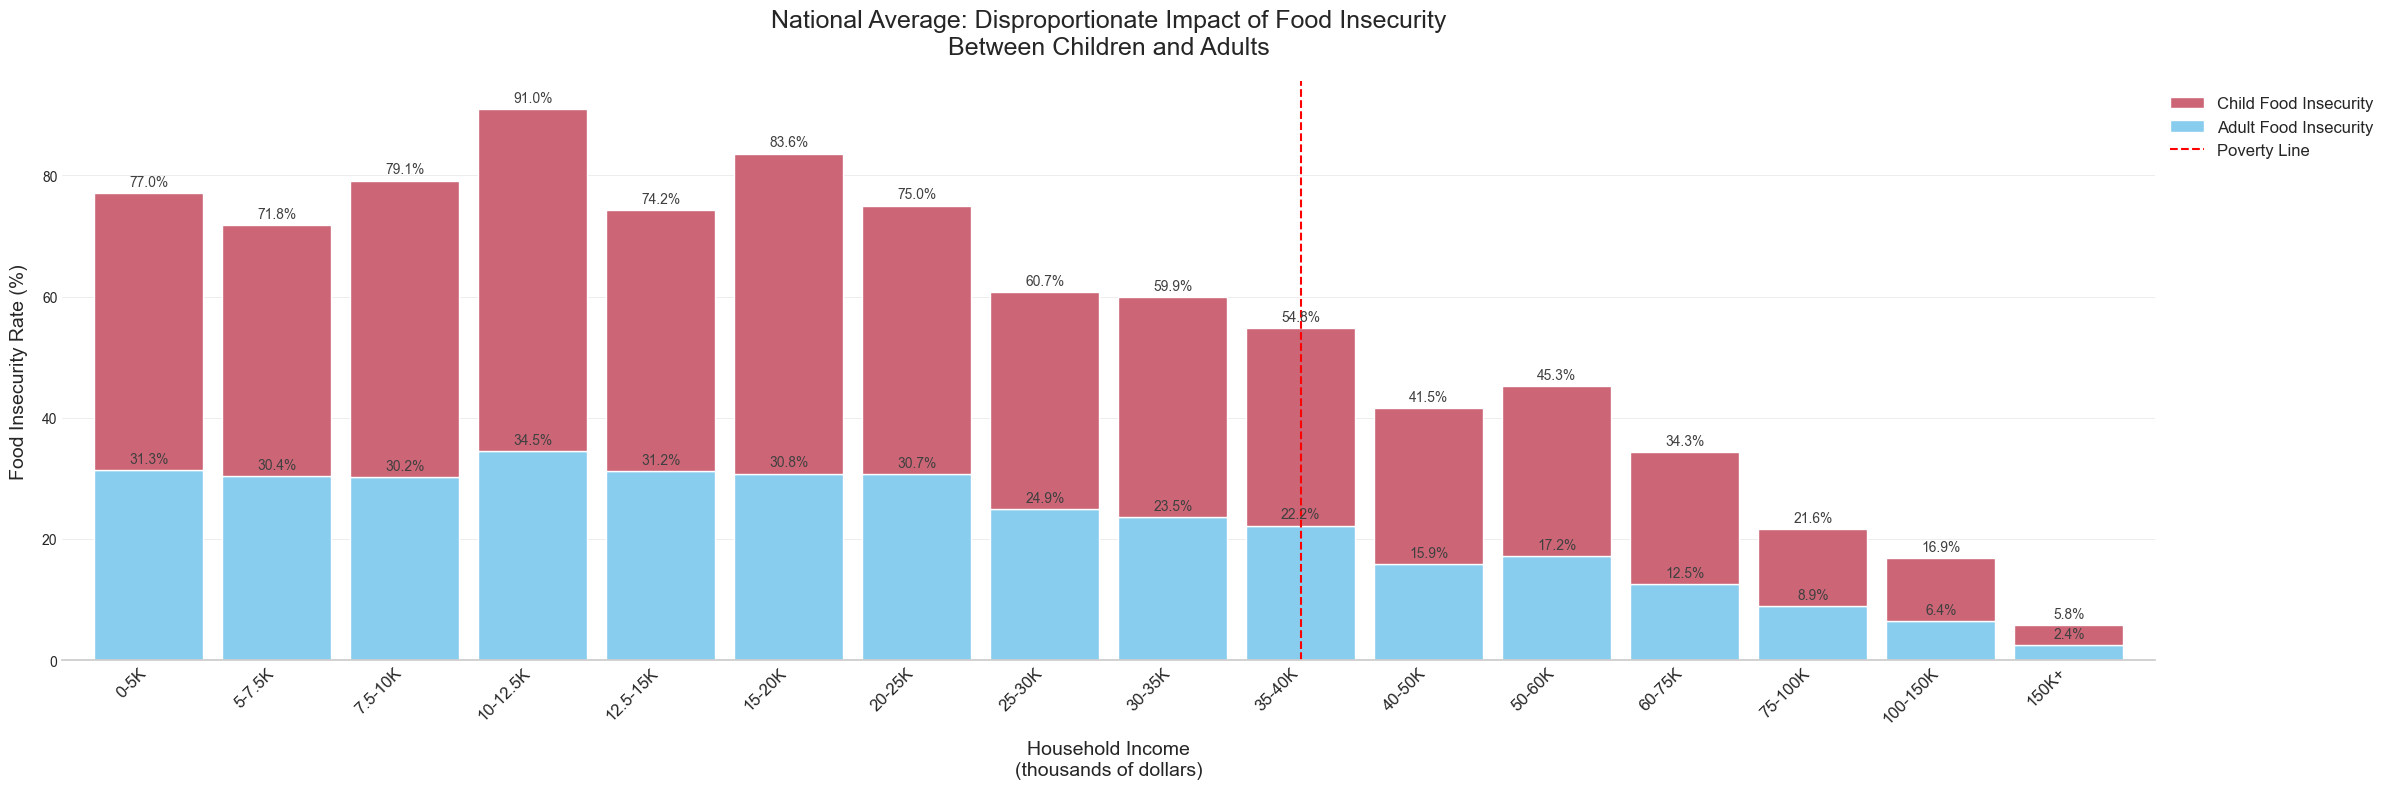

In [242]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def create_combined_security_viz(df):
    df_analysis = df.copy()
    
    # Filter out invalid values
    df_analysis = df_analysis[
        (df_analysis['food_security_status'].isin(['Food Secure', 'Low Food Security', 'Very Low Food Security'])) &
        (df_analysis['family_income'] != -1)
    ]
    
    # Create age category
    df_analysis['age_category'] = np.where(df_analysis['age'] < 18, 'Child (0-17)', 'Adult (18+)')
    
    # Calculate rates
    results = []
    income_mapping = {
        'Less than $5,000': '0-5K',
        '$5,000 to $7,499': '5-7.5K',
        '$7,500 to $9,999': '7.5-10K',
        '$10,000 to $12,499': '10-12.5K',
        '$12,500 to $14,999': '12.5-15K',
        '$15,000 to $19,999': '15-20K',
        '$20,000 to $24,999': '20-25K',
        '$25,000 to $29,999': '25-30K',
        '$30,000 to $34,999': '30-35K',
        '$35,000 to $39,999': '35-40K',
        '$40,000 to $49,999': '40-50K',
        '$50,000 to $59,999': '50-60K',
        '$60,000 to $74,999': '60-75K',
        '$75,000 to $99,999': '75-100K',
        '$100,000 to $149,999': '100-150K',
        '$150,000 or more': '150K+'
    }
    
    income_order = [
        '0-5K', '5-7.5K', '7.5-10K', '10-12.5K', '12.5-15K', 
        '15-20K', '20-25K', '25-30K', '30-35K', '35-40K',
        '40-50K', '50-60K', '60-75K', '75-100K', '100-150K', '150K+'
    ]
    
    for income in df_analysis['family_income'].unique():
        income_group = df_analysis[df_analysis['family_income'] == income]
        
        # Calculate child food insecurity
        child_group = income_group[income_group['age_category'] == 'Child (0-17)']
        child_insecure = (
            (child_group['food_security_status'].isin(['Low Food Security', 'Very Low Food Security']) * 
             child_group['person_supplement_weight']).sum() / 
            child_group['person_supplement_weight'].sum() * 100 if len(child_group) > 0 else 0
        )
        
        # Calculate adult food insecurity
        adult_group = income_group[income_group['age_category'] == 'Adult (18+)']
        adult_insecure = (
            (adult_group['food_security_status'].isin(['Low Food Security', 'Very Low Food Security']) * 
             adult_group['person_supplement_weight']).sum() / 
            adult_group['person_supplement_weight'].sum() * 100 if len(adult_group) > 0 else 0
        )
        
        results.append({
            'family_income': income_mapping.get(income, income),
            'Child Food Insecurity': child_insecure,
            'Adult Food Insecurity': adult_insecure,
            'sample_size': len(income_group)
        })
    
    # Convert to DataFrame and sort by income order
    results_df = pd.DataFrame(results)
    results_df['income_order'] = pd.Categorical(
        results_df['family_income'], 
        categories=income_order, 
        ordered=True
    )
    results_df = results_df.sort_values('income_order')
    
    # Define a colorblind-safe color palette
    color_palette = ['#88CCEE', '#CC6677']  # Color Universal Design (CUD) friendly

    # Create plot
    plt.figure(figsize=(12, 6))
    plt.style.use('seaborn-v0_8-white')
    
    ax = results_df.plot(
        x='family_income',
        y=['Adult Food Insecurity', 'Child Food Insecurity'],
        kind='bar',
        stacked=True,
        color=color_palette,
        width=0.85
    )
    
    # Tufte principles: remove top and right spines, lighten grid lines, focus on key data
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')
    
    # Minimal grid for y-axis only
    ax.yaxis.grid(True, color='#E6E6E6', linestyle='-', linewidth=0.5)
    ax.xaxis.grid(False)
    
    # Poverty line at $35,000-$40,000
    poverty_threshold = '35-40K'
    poverty_idx = income_order.index(poverty_threshold)
    ax.axvline(poverty_idx, color='red', linestyle='--', linewidth=1.5, ymin=0, ymax=1, label='Poverty Line')
    
    # Labeling
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.xlabel('Household Income\n(thousands of dollars)', fontsize=14, labelpad=10)
    plt.ylabel('Food Insecurity Rate (%)', fontsize=14, labelpad=10)
    plt.title('National Average: Disproportionate Impact of Food Insecurity\nBetween Children and Adults', 
              fontsize=18, pad=20)
    
    # Move legend into the plot area, reverse order of labels for clarity
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], title=None, bbox_to_anchor=(1, 1), loc='upper left', frameon=False, fontsize=12)

    # Add percentage labels
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', fontsize=10, padding=3, color='#404040')
    
    # Adjust layout
    plt.tight_layout()
    return plt

# Generate visualization
viz = create_combined_security_viz(df_clean)
viz.show()

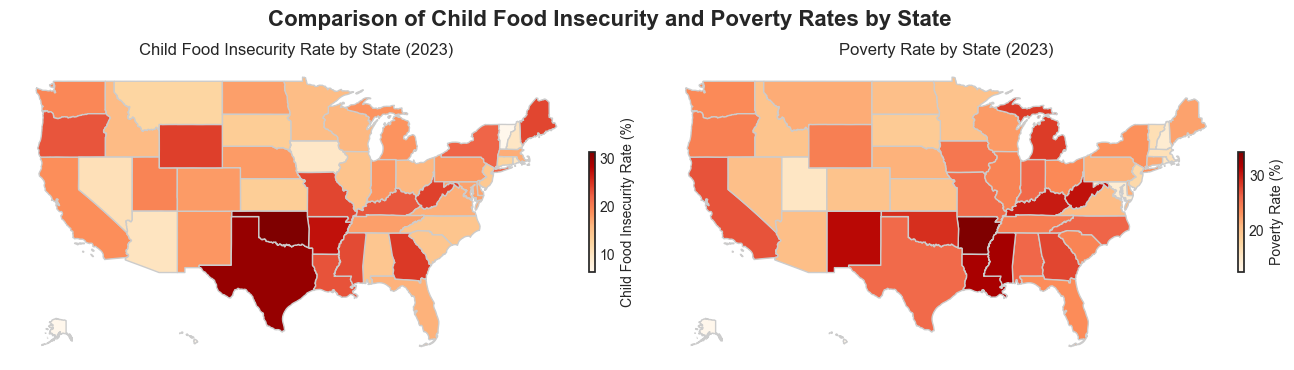

In [237]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def create_tighter_maps(df):
    # Calculate state-level rates for child food insecurity and poverty
    state_results = []
    for state in df['state'].unique():
        state_group = df[df['state'] == state]
        
        child_group = state_group[state_group['age'] < 18]
        child_insecure = (
            (child_group['food_security_status'].isin(['Low Food Security', 'Very Low Food Security']) * 
             child_group['person_supplement_weight']).sum() / 
            child_group['person_supplement_weight'].sum() * 100 if len(child_group) > 0 else 0
        )
        
        poverty_rate = (
            (state_group['poverty_indicator'] == 1).sum() / len(state_group) * 100 if len(state_group) > 0 else 0
        )
        
        state_results.append({
            'state': state,
            'Child Food Insecurity': child_insecure,
            'Poverty Rate': poverty_rate
        })
    
    state_df = pd.DataFrame(state_results)
    
    # Load and merge data with US shapefiles
    us_states = gpd.read_file('https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip')
    us_states['state_name'] = us_states['NAME']
    map_data = us_states.merge(state_df, how='left', left_on='state_name', right_on='state').dropna(subset=['geometry'])

    # Create a compact figure layout
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

    # Color palette
    color_palette = 'OrRd'

    # Plot child food insecurity
    contiguous_us = map_data[~map_data['state_name'].isin(['Alaska', 'Hawaii'])]
    contiguous_us.plot(
        column='Child Food Insecurity',
        ax=ax1,
        cmap=color_palette,
        legend=True,
        edgecolor='0.8',
        legend_kwds={'label': "Child Food Insecurity Rate (%)", 'orientation': "vertical", 'shrink': 0.4, 'fraction': 0.02, 'pad': 0.01}
    )
    ax1.set_title("Child Food Insecurity Rate by State (2023)", fontsize=12)
    ax1.axis('off')

    # Alaska and Hawaii insets for the first map
    ax1_ak = inset_axes(ax1, width="10%", height="10%", loc='lower left', bbox_to_anchor=(0.02, 0.02, 1, 1), bbox_transform=ax1.transAxes)
    alaska = map_data[map_data['state_name'] == 'Alaska']
    alaska.plot(column='Child Food Insecurity', ax=ax1_ak, cmap=color_palette, edgecolor='0.8')
    ax1_ak.set_xlim(-180, -130)
    ax1_ak.set_ylim(50, 72)
    ax1_ak.axis('off')

    ax1_hi = inset_axes(ax1, width="6%", height="6%", loc='lower left', bbox_to_anchor=(0.27, 0.02, 1, 1), bbox_transform=ax1.transAxes)
    hawaii = map_data[map_data['state_name'] == 'Hawaii']
    hawaii.plot(column='Child Food Insecurity', ax=ax1_hi, cmap=color_palette, edgecolor='0.8')
    ax1_hi.set_xlim(-161, -154)
    ax1_hi.set_ylim(18, 23)
    ax1_hi.axis('off')

    # Plot poverty rate
    contiguous_us.plot(
        column='Poverty Rate',
        ax=ax2,
        cmap=color_palette,
        legend=True,
        edgecolor='0.8',
        legend_kwds={'label': "Poverty Rate (%)", 'orientation': "vertical", 'shrink': 0.4, 'fraction': 0.02, 'pad': 0.01}
    )
    ax2.set_title("Poverty Rate by State (2023)", fontsize=12)
    ax2.axis('off')

    # Alaska and Hawaii insets for the second map
    ax2_ak = inset_axes(ax2, width="10%", height="10%", loc='lower left', bbox_to_anchor=(0.02, 0.02, 1, 1), bbox_transform=ax2.transAxes)
    alaska.plot(column='Poverty Rate', ax=ax2_ak, cmap=color_palette, edgecolor='0.8')
    ax2_ak.set_xlim(-180, -130)
    ax2_ak.set_ylim(50, 72)
    ax2_ak.axis('off')

    ax2_hi = inset_axes(ax2, width="6%", height="6%", loc='lower left', bbox_to_anchor=(0.27, 0.02, 1, 1), bbox_transform=ax2.transAxes)
    hawaii.plot(column='Poverty Rate', ax=ax2_hi, cmap=color_palette, edgecolor='0.8')
    ax2_hi.set_xlim(-161, -154)
    ax2_hi.set_ylim(18, 23)
    ax2_hi.axis('off')

    # Main title
    plt.suptitle("Comparison of Child Food Insecurity and Poverty Rates by State", fontsize=16, fontweight='bold', y=0.98)

    # Adjust layout to remove excess space
    plt.subplots_adjust(top=0.85, bottom=0.1, hspace=0.1, wspace=0.1)

    return plt

# Generate and show the updated map
state_maps = create_tighter_maps(df_clean)
state_maps.show()

In [223]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np

# def create_combined_security_viz(df):
#     df_analysis = df.copy()
    
#     # Filter out invalid values
#     df_analysis = df_analysis[
#         (df_analysis['food_security_status'].isin(['Food Secure', 'Low Food Security', 'Very Low Food Security'])) &
#         (df_analysis['family_income'] != -1)
#     ]
    
#     # Create age category
#     df_analysis['age_category'] = np.where(df_analysis['age'] < 18, 'Child (0-17)', 'Adult (18+)')
    
#     # Calculate rates
#     results = []
#     income_mapping = {
#         'Less than $5,000': '0-5K',
#         '$5,000 to $7,499': '5-7.5K',
#         '$7,500 to $9,999': '7.5-10K',
#         '$10,000 to $12,499': '10-12.5K',
#         '$12,500 to $14,999': '12.5-15K',
#         '$15,000 to $19,999': '15-20K',
#         '$20,000 to $24,999': '20-25K',
#         '$25,000 to $29,999': '25-30K',
#         '$30,000 to $34,999': '30-35K',
#         '$35,000 to $39,999': '35-40K',
#         '$40,000 to $49,999': '40-50K',
#         '$50,000 to $59,999': '50-60K',
#         '$60,000 to $74,999': '60-75K',
#         '$75,000 to $99,999': '75-100K',
#         '$100,000 to $149,999': '100-150K',
#         '$150,000 or more': '150K+'
#     }
    
#     # Also create a sorting order
#     income_order = [
#         '0-5K', '5-7.5K', '7.5-10K', '10-12.5K', '12.5-15K', 
#         '15-20K', '20-25K', '25-30K', '30-35K', '35-40K',
#         '40-50K', '50-60K', '60-75K', '75-100K', '100-150K', '150K+'
#     ]
    
#     for income in df_analysis['family_income'].unique():
#         income_group = df_analysis[df_analysis['family_income'] == income]
        
#         # Calculate child food insecurity
#         child_group = income_group[income_group['age_category'] == 'Child (0-17)']
#         child_insecure = (
#             (child_group['food_security_status'].isin(['Low Food Security', 'Very Low Food Security']) * 
#              child_group['person_supplement_weight']).sum() / 
#             child_group['person_supplement_weight'].sum() * 100 if len(child_group) > 0 else 0
#         )
        
#         # Calculate adult food insecurity
#         adult_group = income_group[income_group['age_category'] == 'Adult (18+)']
#         adult_insecure = (
#             (adult_group['food_security_status'].isin(['Low Food Security', 'Very Low Food Security']) * 
#              adult_group['person_supplement_weight']).sum() / 
#             adult_group['person_supplement_weight'].sum() * 100 if len(adult_group) > 0 else 0
#         )
        
#         results.append({
#             'family_income': income_mapping.get(income, income),
#             'Child Food Insecurity': child_insecure,
#             'Adult Food Insecurity': adult_insecure,
#             'sample_size': len(income_group)
#         })
    
#     # Convert to DataFrame and sort by income order
#     results_df = pd.DataFrame(results)
#     results_df['income_order'] = pd.Categorical(
#         results_df['family_income'], 
#         categories=income_order, 
#         ordered=True
#     )
#     results_df = results_df.sort_values('income_order')
    
#     # Create plot with white background
#     plt.figure(figsize=(12, 8))
#     plt.style.use('seaborn-v0_8-white')
    
#     # Create stacked bars
#     ax = results_df.plot(
#         x='family_income',
#         y=['Adult Food Insecurity', 'Child Food Insecurity'],  # Keep Adult first in the column order
#         kind='bar',
#         stacked=True,
#         color=['#A5C5E6', '#E6A5A5'],  # Ensure colors match the order
#         width=0.85
#     )
    
#     # Remove top and right spines
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
    
#     # Lighten the grid
#     ax.grid(axis='y', color='#E6E6E6', linestyle='-', linewidth=0.5)
    
#     # Customize the plot
#     plt.xticks(rotation=45, ha='right', fontsize=12)
#     plt.xlabel('Household Income (thousands)', fontsize=14, labelpad=10)
#     plt.ylabel('Food Insecurity Rate (%)', fontsize=14, labelpad=10)
#     plt.title('National Average: Disproportionate Impact of Food Insecurity\nBetween Children and Adults', 
#               fontsize=16, pad=20)
    
#     # Move legend into the plot area
#     plt.legend(title=None,
#               bbox_to_anchor=(0.98, 0.98),
#               loc='upper right',
#               frameon=False,
#               fontsize=12)
    
#     # Add percentage labels
#     for c in ax.containers:
#         ax.bar_label(c, fmt='%.1f%%', fontsize=10, padding=3, color='#404040')
    
#     # Reverse the order of the legend labels
#     handles, labels = ax.get_legend_handles_labels()
#     ax.legend(handles[::-1], labels[::-1], title=None, bbox_to_anchor=(0.98, 0.98), loc='upper right', frameon=False, fontsize=12)

#     # Adjust layout
#     plt.tight_layout()

#     return plt

# # Generate visualization
# create_combined_security_viz(df_clean).show()

/var/folders/gb/trvj_2v15pl3fy6jg40wrk1w0000gn/T/ipykernel_1836/3933319749.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(h_pad=2)


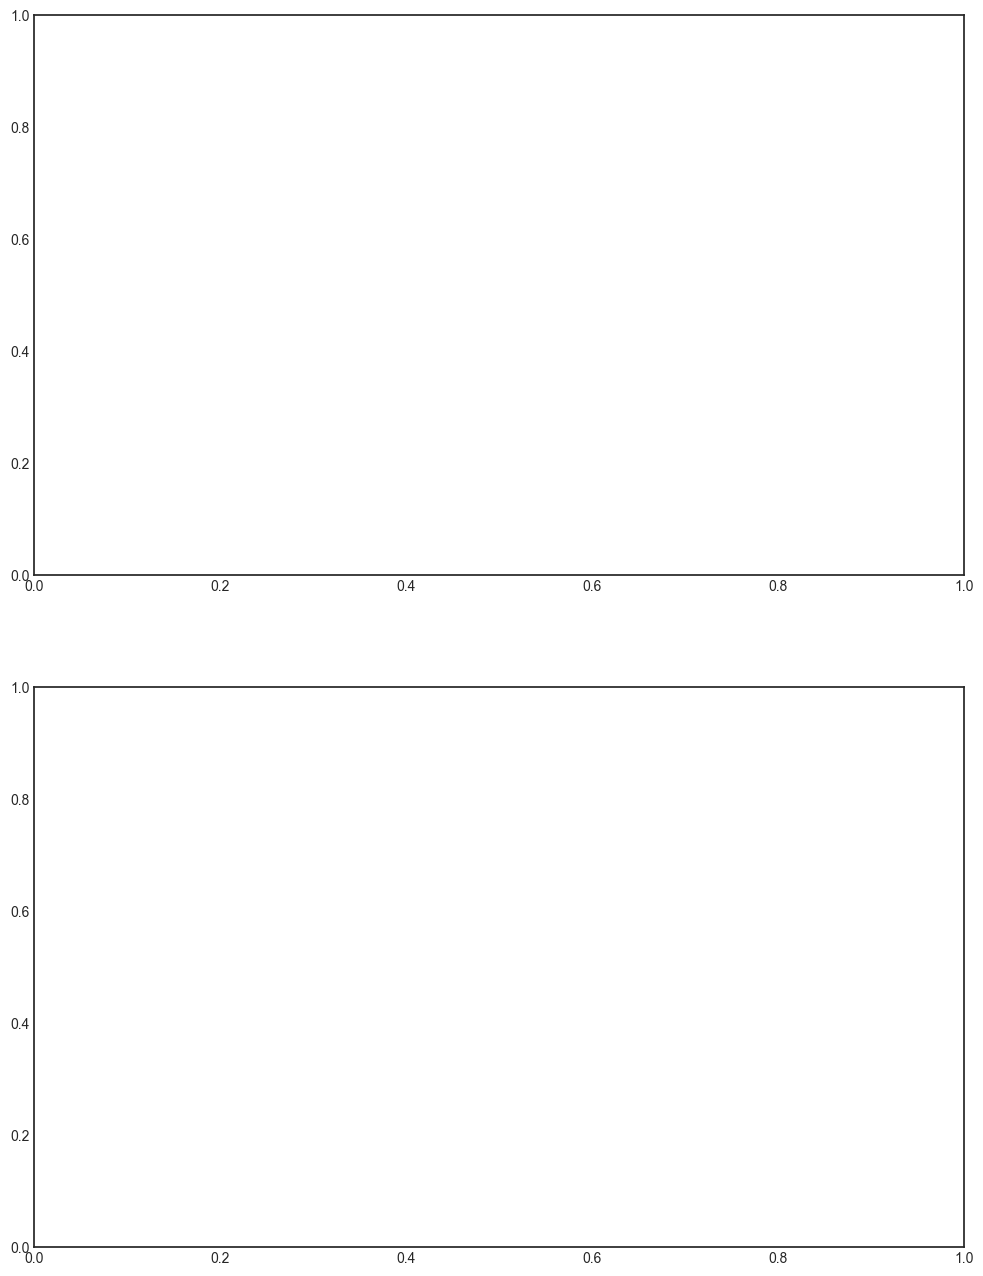

<Figure size 1200x600 with 0 Axes>

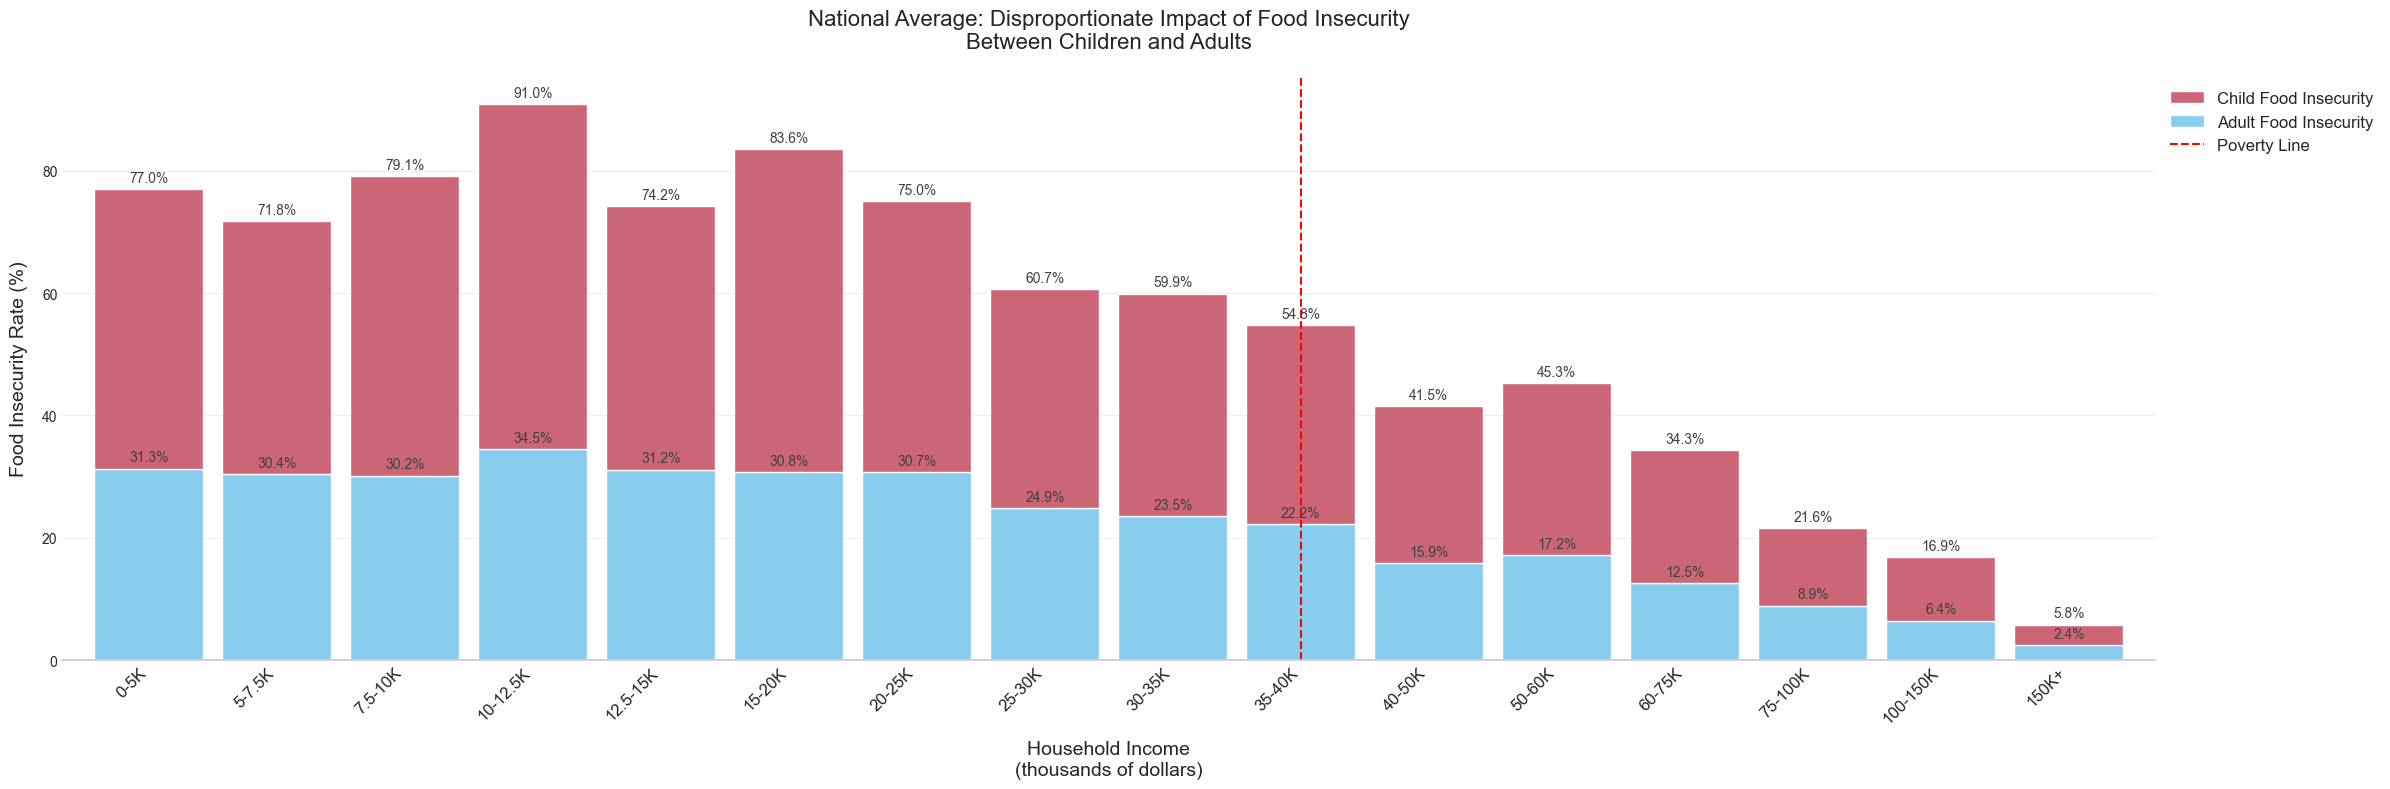

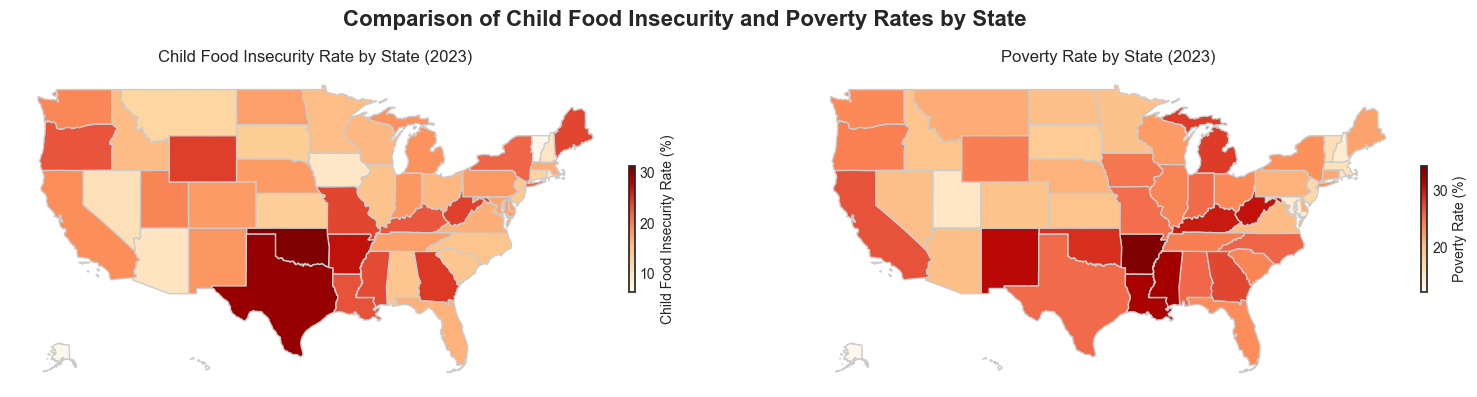

In [241]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Define the layout with GridSpec
fig = plt.figure(figsize=(12, 16))  # Adjust the figure size as needed
gs = GridSpec(2, 1, height_ratios=[1, 1])  # Two rows, one for each visualization

# Create the first visualization (bar chart)
ax1 = fig.add_subplot(gs[0])
create_combined_security_viz(df_clean).axes = ax1  # Assuming `create_combined_security_viz` returns a plot

# Create the second visualization (side-by-side maps)
ax2 = fig.add_subplot(gs[1])
create_tighter_maps(df_clean).axes = ax2  # Assuming `create_state_map_compact_layout` returns a plot

# Adjust the spacing between the two visualizations
plt.tight_layout(h_pad=2)

# Display the combined figure
plt.show()